Import Error: GridMap_Interface not found!


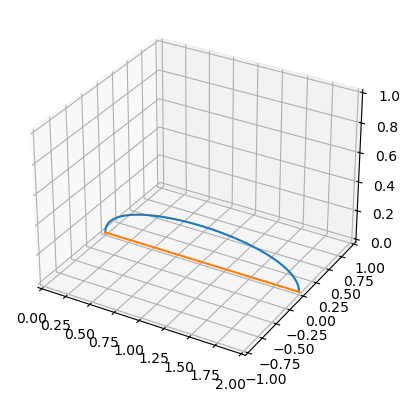

In [1]:
import sys
import os
from matplotlib import projections
# Directory Management
try:
    # Run in Terminal
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
except:
    # Run in ipykernel & interactive
    ROOT_DIR = os.getcwd()
if ".." not in sys.path:
    sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from fast_legged_planner_py.swing_leg_planner.traj_gen.traj_gen import HermiteSpline
from fast_legged_planner_py.swing_leg_planner.traj_opt.traj_opt import TrajOptProblem
from fast_legged_planner_py.swing_leg_planner.cost.cost import CostCollection, KinematicCost
p0 = np.array([0, 0, 0])
v0 = np.array([0, 0, 1])
p1 = np.array([1, 0, 1])
v1 = np.array([1, 0, 0])
p2 = np.array([2, 0, 0])
v2 = np.array([0, 0, -1])
# Init State
# init_state = np.array([p0, v0, p1, v1, p2, v2])
init_state = np.array([p0, v0, p2, v2])
ts = np.linspace(0, 1, 50)

spline = HermiteSpline(init_state)
# Plot
ax = plt.subplot(1, 1, 1, projection='3d')
ax.set_ylim(-1, 1)
ax.set_xlim(0, 2)
ax.set_zlim(0, 1)
ax.plot3D([spline.evaluate(t)[0] for t in ts], [spline.evaluate(t)[1] for t in ts], [spline.evaluate(t)[2] for t in ts])
# Cost
kine_cost = KinematicCost(spline)
cost_collection = CostCollection([kine_cost])
# Optimize
prob = TrajOptProblem(spline, cost_collection, None, init_state)
opt_state = prob.optimize(maxiter=1000)
# print(opt_state)
# Plot
ax.plot3D([spline.evaluate(t)[0] for t in ts], [spline.evaluate(t)[1] for t in ts], [spline.evaluate(t)[2] for t in ts])
